In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/csqa-logicalcombinations/test_all_hf.json
/kaggle/input/csqa-logicalcombinations/dev_all_hf.json
/kaggle/input/csqa-logicalcombinations/test_logical_combinations_output.json
/kaggle/input/csqa-logicalcombinations/dev_logical_combinations_output.json
/kaggle/input/csqa-logicalcombinations/logical_combinations_output.json
/kaggle/input/csqa-logicalcombinations/train_logical_combinations_output.json
/kaggle/input/csqa-logicalcombinations/train_all_hf.json


In [ ]:
import pandas as pd
import json

with open("/kaggle/input/csqa-logicalcombinations/train_logical_combinations_output.json", "r") as f:
    data = json.load(f)

train_df = pd.DataFrame(data["questions"])
train_df.to_csv('train_logical_combinations_output.csv',index=False)

train_df.head()

with open("/kaggle/input/csqa-logicalcombinations/dev_logical_combinations_output.json", "r") as f:
    data = json.load(f)

dev_df = pd.DataFrame(data["questions"])
dev_df.to_csv('dev_logical_combinations_output.csv',index=False)

dev_df.head()


with open("/kaggle/input/csqa-logicalcombinations/test_logical_combinations_output.json", "r") as f:
    data = json.load(f)

test_df = pd.DataFrame(data["questions"])
test_df.to_csv('test_logical_combinations_output.csv',index=False)

test_df.head()

In [ ]:
import pandas as pd
import random
import ast

df = pd.read_csv("/kaggle/working/train_logical_combinations_output.csv")  # replace with your file

def safe_eval(val):
    if isinstance(val, list):
        return val
    if pd.isna(val):
        return []
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except:
            return []
    return []

df['logical_combinations'] = df['logical_combinations'].apply(safe_eval)

qa_sets = {
    'AND': [],
    'OR': [],
    'NEITHER': [],
    'Mixed': []
}

class LabelRotator:
    def __init__(self, name):
        self.name = name
        self.labels = ['A', 'B', 'C', 'D']
        self.current_index = 0
    
    def get_next_label(self):
        label = self.labels[self.current_index]
        self.current_index = (self.current_index + 1) % len(self.labels)
        return label

rotators = {
    'AND': LabelRotator('AND'),
    'OR': LabelRotator('OR'),
    'NEITHER': LabelRotator('NEITHER'),
    'Mixed': LabelRotator('Mixed')
}

def create_qa_item(question, correct_ans, incorrect_ans, qa_type):
    """Helper function to create a QA item with proper label rotation"""
    
    correct_label = rotators[qa_type].get_next_label()
    
    if len(incorrect_ans) < 3:
        print(f"Warning: Only {len(incorrect_ans)} incorrect answers available for {qa_type}")
        return None
    
    selected_incorrect = random.sample(incorrect_ans, 3)
    
    options = [''] * 4
    
    correct_pos = rotators[qa_type].labels.index(correct_label)
    options[correct_pos] = correct_ans
    
    incorrect_positions = [i for i in range(4) if i != correct_pos]
    for i, pos in enumerate(incorrect_positions):
        options[pos] = selected_incorrect[i]
    
    return {
        'question': question,
        'A': options[0],
        'B': options[1],
        'C': options[2],
        'D': options[3],
        'correct_label': correct_label,
        'correct_answer_text': correct_ans,
        'qa_type': qa_type
    }

type_counts = {'AND': 0, 'OR': 0, 'NEITHER': 0, 'Mixed': 0}

for idx, row in df.iterrows():
    question = row['question']
    combos = row['logical_combinations']
    
    and_correct = combos.get('AND_combinations', {}).get('correct', [])
    and_incorrect = combos.get('AND_combinations', {}).get('incorrect', [])
    
    or_correct = combos.get('OR_combinations', {}).get('correct', [])
    or_incorrect = combos.get('OR_combinations', {}).get('incorrect', [])
    
    neither_correct = combos.get('NEITHER_combinations', {}).get('correct', [])
    neither_incorrect = combos.get('NEITHER_combinations', {}).get('incorrect', [])
    
    if and_correct and len(and_incorrect) >= 3:
        correct_ans = random.choice(and_correct)
        qa_item = create_qa_item(question, correct_ans, and_incorrect, 'AND')
        if qa_item:
            qa_sets['AND'].append(qa_item)
            type_counts['AND'] += 1
    
    if or_correct and len(or_incorrect) >= 3:
        correct_ans = random.choice(or_correct)
        qa_item = create_qa_item(question, correct_ans, or_incorrect, 'OR')
        if qa_item:
            qa_sets['OR'].append(qa_item)
            type_counts['OR'] += 1
    
    if neither_correct and len(neither_incorrect) >= 3:
        correct_ans = random.choice(neither_correct)
        qa_item = create_qa_item(question, correct_ans, neither_incorrect, 'NEITHER')
        if qa_item:
            qa_sets['NEITHER'].append(qa_item)
            type_counts['NEITHER'] += 1
    
    all_correct_types = [
        ('AND', and_correct),
        ('OR', or_correct),
        ('NEITHER', neither_correct)
    ]
    all_incorrect_types = and_incorrect + or_incorrect + neither_incorrect
    
    valid_categories = [cat for cat, lst in all_correct_types if lst]
    if valid_categories and len(all_incorrect_types) >= 3:
        chosen_category = random.choice(valid_categories)
        chosen_correct_list = dict(all_correct_types)[chosen_category]
        correct_ans = random.choice(chosen_correct_list)
        qa_item = create_qa_item(question, correct_ans, all_incorrect_types, 'Mixed')
        if qa_item:
            qa_sets['Mixed'].append(qa_item)
            type_counts['Mixed'] += 1

print(f"\n=== GENERATION COMPLETE ===")
for qtype, count in type_counts.items():
    print(f"{qtype}: {count} questions generated")

for key, qlist in qa_sets.items():
    if qlist:  # Only save if we have questions
        df_out = pd.DataFrame(qlist)
        df_out.to_csv(f'train_qa_{key}.csv', index=False)
        print(f"\n{key} QA saved: {len(df_out)} questions in train_qa_{key}.csv")
        
        label_counts = df_out['correct_label'].value_counts().sort_index()
        print(f"  Label distribution: {dict(label_counts)}")
        
        print(f"  Label sequence (first 8): {list(df_out['correct_label'].head(8))}")
    else:
        print(f"{key}: No valid QA pairs generated")

total_questions = sum(len(qlist) for qlist in qa_sets.values())
print(f"\nFinal total questions generated: {total_questions}")

In [ ]:
import pandas as pd

and_df = pd.read_csv("train_qa_AND.csv")
or_df = pd.read_csv("train_qa_OR.csv")
neither_df = pd.read_csv("train_qa_NEITHER.csv")
mixed_df = pd.read_csv("train_qa_Mixed.csv")

train_df = pd.concat([and_df, or_df, neither_df, mixed_df], ignore_index=True)
train_df.to_csv("train_all.csv", index=False)


and_df = pd.read_csv("dev_qa_AND.csv")
or_df = pd.read_csv("dev_qa_OR.csv")
neither_df = pd.read_csv("dev_qa_NEITHER.csv")
mixed_df = pd.read_csv("dev_qa_Mixed.csv")

dev_df = pd.concat([and_df, or_df, neither_df, mixed_df], ignore_index=True)
dev_df.to_csv("dev_all.csv", index=False)


and_df = pd.read_csv("test_qa_AND.csv")
or_df = pd.read_csv("test_qa_OR.csv")
neither_df = pd.read_csv("test_qa_NEITHER.csv")
mixed_df = pd.read_csv("test_qa_Mixed.csv")

test_df = pd.concat([and_df, or_df, neither_df, mixed_df], ignore_index=True)
test_df.to_csv("test_all.csv", index=False)


In [ ]:
label_map = {"A": 0, "B": 1, "C": 2, "D": 3}

train_df["choices"] = train_df.apply(lambda r: [r["A"], r["B"], r["C"], r["D"]], axis=1)
train_df["label"] = train_df["correct_label"].map(label_map)

hf_train_df = train_df[["question", "choices", "label", "qa_type"]]

hf_train_df.to_json("train_all_hf.json", orient="records", lines=True)

dev_df["choices"] = dev_df.apply(lambda r: [r["A"], r["B"], r["C"], r["D"]], axis=1)
dev_df["label"] = dev_df["correct_label"].map(label_map)

hf_dev_df = dev_df[["question", "choices", "label","qa_type"]]

hf_dev_df.to_json("dev_all_hf.json", orient="records", lines=True)


test_df["choices"] = test_df.apply(lambda r: [r["A"], r["B"], r["C"], r["D"]], axis=1)
test_df["label"] = test_df["correct_label"].map(label_map)

hf_test_df = test_df[["question", "choices", "label","qa_type"]]

hf_test_df.to_json("test_all_hf.json", orient="records", lines=True)



In [10]:

!pip install --upgrade --no-cache-dir protobuf==3.20.3

import sys
print("Python version:", sys.version)

try:
    import pyarrow as pa
    print(f"✓ PyArrow {pa.__version__}")
except Exception as e:
    print(f"✗ PyArrow failed: {e}")

try:
    import datasets
    print(f"✓ Datasets {datasets.__version__}")
except Exception as e:
    print(f"✗ Datasets failed: {e}")

try:
    from transformers import __version__
    print(f"✓ Transformers {__version__}")
except Exception as e:
    print(f"✗ Transformers failed: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-me

In [12]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 38.2 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 19.0.1
    Uninstalling pyarrow-19.0.1:
      Successfully uninstalled pyarrow-19.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pylibcudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.2.2 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
cudf-polars-cu12 25.6.0 requires pylibcudf-cu12=

2025-11-15 08:53:10.801962: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763196790.992369      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763196791.046766      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered



Training Configuration:
  max_epochs: 10
  patience: 3
  min_delta: 0.001
  batch_size: 4
  learning_rate: 5e-05
  warmup_steps: 500
  gradient_accumulation_steps: 2
  weight_decay: 0.01
  max_length: 512


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

...


Model: google/flan-t5-base | Epoch 9

Type         Accuracy     Macro-P      Macro-R      Macro-F1     Support   
----------------------------------------------------------------------------------------------------
AND              0.9087     0.9090     0.9087     0.9087     1500
Mixed            0.8700     0.8700     0.8700     0.8700     1500
NEITHER          0.9100     0.9103     0.9100     0.9101     1500
OR               0.9433     0.9436     0.9433     0.9433     1500
----------------------------------------------------------------------------------------------------
Macro Avg        0.9080     0.9082     0.9080     0.9080        -
Micro Avg        0.9080     0.9080     0.9080     0.9080     6000

No improvement for 2 epoch(s) (current Macro F1: 0.9080, best: 0.9070)

Epoch 10/10


Training:   0%|          | 0/2999 [00:00<?, ?it/s]


Train Loss: 0.0188

Evaluating...


Evaluating:   0%|          | 0/1500 [00:00<?, ?it/s]


Model: google/flan-t5-base | Epoch 10

Type         Accuracy     Macro-P      Macro-R      Macro-F1     Support   
----------------------------------------------------------------------------------------------------
AND              0.9073     0.9077     0.9073     0.9074     1500
Mixed            0.8727     0.8727     0.8727     0.8727     1500
NEITHER          0.9100     0.9103     0.9100     0.9101     1500
OR               0.9447     0.9450     0.9447     0.9446     1500
----------------------------------------------------------------------------------------------------
Macro Avg        0.9087     0.9089     0.9087     0.9087        -
Micro Avg        0.9087     0.9087     0.9087     0.9087     6000

New best Macro F1: 0.9087 (improvement 0.0017). Saving to ./google-flan-t5-base-best

Training Complete.
Model: google/flan-t5-base
Best Epoch: 10/10
Best Macro F1: 0.9087

Final Best Results:

Type         Accuracy     Macro-P      Macro-R      Macro-F1     Support   
---------------

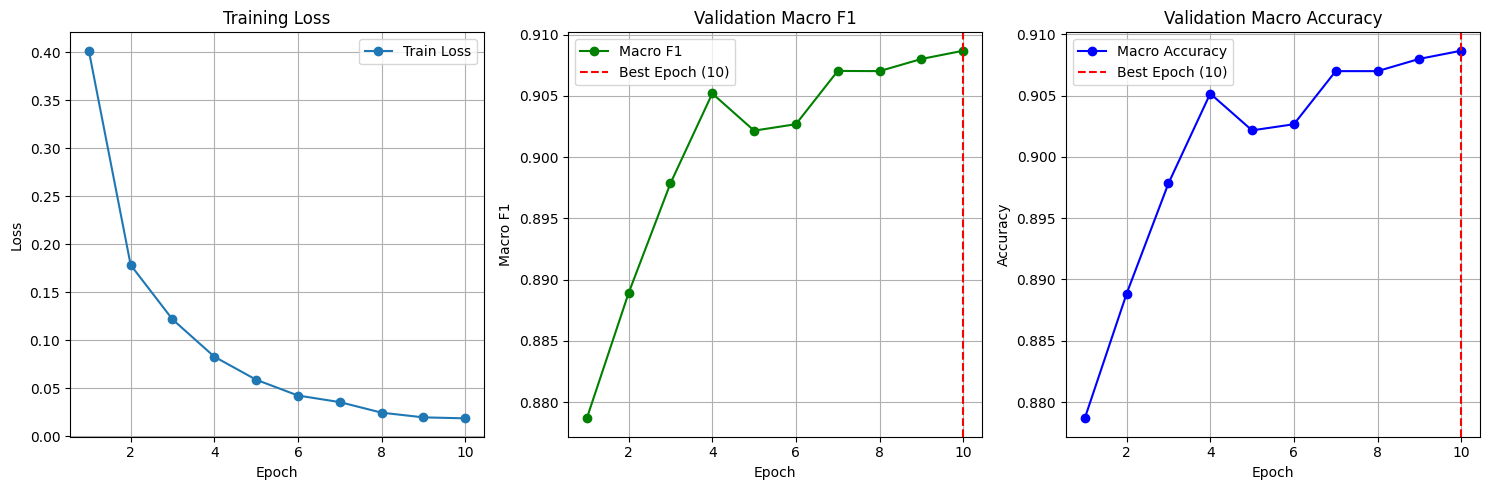

In [14]:
from transformers import T5Tokenizer, T5ForConditionalGeneration, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
import torch
from torch.optim import AdamW
from tqdm.auto import tqdm
import json
from collections import defaultdict
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt

model_name = "google/flan-t5-base"

training_config = {
    'max_epochs': 10,
    'patience': 3,  # Early stopping patience
    'min_delta': 0.001,  # Minimum improvement to count
    'batch_size': 4,
    'learning_rate': 5e-5,
    'warmup_steps': 500,
    'gradient_accumulation_steps': 2,
    'weight_decay': 0.01,
    'max_length': 512
}

print("\nTraining Configuration:")
for key, value in training_config.items():
    print(f"  {key}: {value}")

tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

class T5MCQADataset(Dataset):
    def __init__(self, json_path, tokenizer, max_length=512):
        self.data = []
        with open(json_path, 'r') as f:
            for line in f:
                if line.strip():
                    self.data.append(json.loads(line.strip()))
        self.tokenizer = tokenizer
        self.max_length = max_length
        print(f"Loaded {len(self.data)} examples from {json_path}")
        
        type_counts = defaultdict(int)
        for item in self.data:
            type_counts[item.get("qa_type", "unknown")] += 1
        print("Dataset composition:")
        for qa_type, count in sorted(type_counts.items()):
            print(f"  {qa_type}: {count} ({count/len(self.data)*100:.1f}%)")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        question = item["question"]
        choices = item["choices"]
        label = item["label"]
        qa_type = item.get("qa_type", "unknown")
        
        input_text = f"question: {question} "
        for i, choice in enumerate(choices):
            input_text += f"choice {chr(65+i)}: {choice} "
        
        target_text = chr(65 + label)
        
        input_encoding = self.tokenizer(
            input_text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        
        target_encoding = self.tokenizer(
            target_text,
            max_length=2,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        
        return {
            "input_ids": input_encoding["input_ids"].squeeze(),
            "attention_mask": input_encoding["attention_mask"].squeeze(),
            "labels": target_encoding["input_ids"].squeeze(),
            "qa_type": qa_type,
            "correct_label": label
        }

def compute_metrics_by_type(predictions, labels, qa_types):
    """Compute comprehensive metrics"""
    predictions = np.array(predictions)
    labels = np.array(labels)
    qa_types = np.array(qa_types)
    
    unique_types = sorted([t for t in set(qa_types) if t != 'overall'])
    
    results = {
        'per_type': {},
        'macro_across_types': {},
        'micro_overall': {},
        'confusion_matrices': {}
    }
    
    for qa_type in unique_types:
        mask = qa_types == qa_type
        type_preds = predictions[mask]
        type_labels = labels[mask]
        
        if len(type_preds) == 0:
            continue
        
        macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
            type_labels, type_preds, average='macro', zero_division=0, labels=[0, 1, 2, 3]
        )
        
        micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
            type_labels, type_preds, average='micro', zero_division=0, labels=[0, 1, 2, 3]
        )
        
        per_class_precision, per_class_recall, per_class_f1, per_class_support = precision_recall_fscore_support(
            type_labels, type_preds, average=None, zero_division=0, labels=[0, 1, 2, 3]
        )
        
        accuracy = (type_preds == type_labels).mean()
        
        results['per_type'][qa_type] = {
            'macro': {
                'precision': macro_precision,
                'recall': macro_recall,
                'f1': macro_f1,
            },
            'micro': {
                'precision': micro_precision,
                'recall': micro_recall,
                'f1': micro_f1,
                'accuracy': accuracy,
            },
            'per_choice': {
                f'choice_{i}': {
                    'precision': per_class_precision[i],
                    'recall': per_class_recall[i],
                    'f1': per_class_f1[i],
                    'support': per_class_support[i]
                } for i in range(4)
            },
            'support': len(type_preds),
            'correct': (type_preds == type_labels).sum()
        }
        
        results['confusion_matrices'][qa_type] = confusion_matrix(
            type_labels, type_preds, labels=[0, 1, 2, 3]
        )
    
    macro_across_types_precision = np.mean([results['per_type'][t]['macro']['precision'] for t in unique_types])
    macro_across_types_recall = np.mean([results['per_type'][t]['macro']['recall'] for t in unique_types])
    macro_across_types_f1 = np.mean([results['per_type'][t]['macro']['f1'] for t in unique_types])
    macro_across_types_accuracy = np.mean([results['per_type'][t]['micro']['accuracy'] for t in unique_types])
    
    results['macro_across_types'] = {
        'precision': macro_across_types_precision,
        'recall': macro_across_types_recall,
        'f1': macro_across_types_f1,
        'accuracy': macro_across_types_accuracy
    }
    
    micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
        labels, predictions, average='micro', zero_division=0, labels=[0, 1, 2, 3]
    )
    micro_accuracy = (predictions == labels).mean()
    
    results['micro_overall'] = {
        'accuracy': micro_accuracy,
        'precision': micro_precision,
        'recall': micro_recall,
        'f1': micro_f1,
        'support': len(predictions),
        'correct': (predictions == labels).sum()
    }
    
    return results

def evaluate_comprehensive(model, dataloader, tokenizer, device):
    """Comprehensive evaluation for T5"""
    model.eval()
    
    all_predictions = []
    all_labels = []
    all_types = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            correct_labels = batch["correct_label"]
            qa_types = batch["qa_type"]
            
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=1,
                num_beams=1,
                do_sample=False,
            )
            
            for i, output in enumerate(outputs):
                decoded = tokenizer.decode(output, skip_special_tokens=True).strip()
                
                if len(decoded) > 0 and decoded[0] in ["A", "B", "C", "D"]:
                    pred_label = ord(decoded[0]) - ord("A")
                else:
                    pred_label = 0
                
                all_predictions.append(pred_label)
                all_labels.append(correct_labels[i].item())
                all_types.append(qa_types[i])
    
    metrics = compute_metrics_by_type(all_predictions, all_labels, all_types)
    return metrics

def print_results_table(metrics, epoch=None, model_name=None):
    """Print results table"""
    
    if epoch is not None:
        print(f"\n{'='*100}")
        if model_name:
            print(f"Model: {model_name} | Epoch {epoch}")
        print(f"{'='*100}")
    
    print(f"\n{'Type':<12} {'Accuracy':<12} {'Macro-P':<12} {'Macro-R':<12} {'Macro-F1':<12} {'Support':<10}")
    print("-" * 100)
    
    for qa_type in sorted(metrics['per_type'].keys()):
        m_macro = metrics['per_type'][qa_type]['macro']
        m_micro = metrics['per_type'][qa_type]['micro']
        support = metrics['per_type'][qa_type]['support']
        
        print(f"{qa_type:<12} {m_micro['accuracy']:>10.4f} {m_macro['precision']:>10.4f} "
              f"{m_macro['recall']:>10.4f} {m_macro['f1']:>10.4f} {support:>8}")
    
    print("-" * 100)
    
    m = metrics['macro_across_types']
    print(f"{'Macro Avg':<12} {m['accuracy']:>10.4f} {m['precision']:>10.4f} "
          f"{m['recall']:>10.4f} {m['f1']:>10.4f} {'-':>8}")
    
    m = metrics['micro_overall']
    print(f"{'Micro Avg':<12} {m['accuracy']:>10.4f} {m['precision']:>10.4f} "
          f"{m['recall']:>10.4f} {m['f1']:>10.4f} {m['support']:>8}")
    
    print("=" * 100)

train_dataset = T5MCQADataset("/kaggle/input/csqa-logicalcombinations/train_all_hf.json", 
                              tokenizer, max_length=training_config['max_length'])
eval_dataset = T5MCQADataset("/kaggle/input/csqa-logicalcombinations/dev_all_hf.json", 
                             tokenizer, max_length=training_config['max_length'])

batch_size = training_config['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
eval_loader = DataLoader(eval_dataset, batch_size=batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
model.to(device)

optimizer = AdamW(model.parameters(), 
                 lr=training_config['learning_rate'], 
                 weight_decay=training_config['weight_decay'])
num_training_steps = training_config['max_epochs'] * len(train_loader) // training_config['gradient_accumulation_steps']
lr_scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=training_config['warmup_steps'],
    num_training_steps=num_training_steps
)

best_macro_f1 = 0
best_epoch = 0
epochs_without_improvement = 0
best_metrics = None
training_history = []

print(f"\n{'='*100}")
print(f"Training {model_name} with Early Stopping")
print(f"Max Epochs: {training_config['max_epochs']}, Patience: {training_config['patience']}")
print(f"{'='*100}")

for epoch in range(training_config['max_epochs']):
    print(f"\n{'='*100}")
    print(f"Epoch {epoch + 1}/{training_config['max_epochs']}")
    print(f"{'='*100}")
    
    model.train()
    total_loss = 0
    optimizer.zero_grad()
    
    progress_bar = tqdm(train_loader, desc="Training")
    for step, batch in enumerate(progress_bar):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        
        labels[labels == tokenizer.pad_token_id] = -100
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels  # This is all you need for training
        )
        loss = outputs.loss / training_config['gradient_accumulation_steps']
        
        loss.backward()
        
        if (step + 1) % training_config['gradient_accumulation_steps'] == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
        
        total_loss += loss.item() * training_config['gradient_accumulation_steps']
        progress_bar.set_postfix({"loss": f"{total_loss / (step + 1):.4f}"})
    
    avg_train_loss = total_loss / len(train_loader)
    print(f"\nTrain Loss: {avg_train_loss:.4f}")
    
    print("\nEvaluating...")
    metrics = evaluate_comprehensive(model, eval_loader, tokenizer, device)
    print_results_table(metrics, epoch=epoch + 1, model_name=model_name)
    
    macro_f1 = metrics['macro_across_types']['f1']
    macro_acc = metrics['macro_across_types']['accuracy']
    
    training_history.append({
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'macro_f1': macro_f1,
        'macro_accuracy': macro_acc,
        'macro_precision': metrics['macro_across_types']['precision'],
        'macro_recall': metrics['macro_across_types']['recall']
    })
    
    improvement = macro_f1 - best_macro_f1
    
    if improvement > training_config['min_delta']:
        best_macro_f1 = macro_f1
        best_epoch = epoch + 1
        best_metrics = metrics
        epochs_without_improvement = 0
        
        save_dir = f"./{model_name.replace('/', '-')}-best"
        print(f"\nNew best Macro F1: {macro_f1:.4f} (improvement {improvement:.4f}). Saving to {save_dir}")
        model.save_pretrained(save_dir)
        tokenizer.save_pretrained(save_dir)
        
        def convert_to_serializable(obj):
            if isinstance(obj, dict):
                return {k: convert_to_serializable(v) for k, v in obj.items()}
            elif isinstance(obj, (np.integer, np.floating)):
                return float(obj)
            elif isinstance(obj, np.ndarray):
                return obj.tolist()
            return obj
        
        results_for_paper = {
            'model': model_name,
            'best_epoch': best_epoch,
            'training_config': training_config,
            'training_history': training_history,
            'best_metrics': convert_to_serializable(best_metrics)
        }
        
        with open(f"{save_dir}/results_detailed.json", "w") as f:
            json.dump(results_for_paper, f, indent=2)
    else:
        epochs_without_improvement += 1
        print(f"\nNo improvement for {epochs_without_improvement} epoch(s) "
              f"(current Macro F1: {macro_f1:.4f}, best: {best_macro_f1:.4f})")
    
    if epochs_without_improvement >= training_config['patience']:
        print(f"\n{'='*100}")
        print("Early stopping triggered.")
        print(f"Best Macro F1: {best_macro_f1:.4f} at epoch {best_epoch}")
        print(f"Training stopped at epoch {epoch + 1}")
        print(f"{'='*100}")
        break

print(f"\n{'='*100}")
print("Training Complete.")
print(f"{'='*100}")
print(f"Model: {model_name}")
print(f"Best Epoch: {best_epoch}/{epoch + 1}")
print(f"Best Macro F1: {best_macro_f1:.4f}")
print(f"{'='*100}")

if best_metrics:
    print("\nFinal Best Results:")
    print_results_table(best_metrics, model_name=model_name)

plt.figure(figsize=(15, 5))

epochs_list = [h['epoch'] for h in training_history]

plt.subplot(1, 3, 1)
plt.plot(epochs_list, [h['train_loss'] for h in training_history], marker='o', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_list, [h['macro_f1'] for h in training_history], marker='o', color='green', label='Macro F1')
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Macro F1')
plt.title('Validation Macro F1')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_list, [h['macro_accuracy'] for h in training_history], marker='o', color='blue', label='Macro Accuracy')
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Macro Accuracy')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig(f'{model_name.replace("/", "-")}_training_curves.png', dpi=300, bbox_inches='tight')
print(f"\nSaved training curves to {model_name.replace('/', '-')}_training_curves.png")

print("\n" + "="*100)
print("SUMMARY FOR PAPER:")
print("="*100)
print(f"Model: {model_name}")
print(f"Best Epoch: {best_epoch}")
print(f"Total Epochs Trained: {len(training_history)}")
print(f"Converged: {'Yes (early stopping)' if epochs_without_improvement >= training_config['patience'] else 'No (completed all epochs)'}")
print(f"Best Validation Macro F1: {best_macro_f1:.4f}")
print(f"Best Validation Macro Accuracy: {best_metrics['macro_across_types']['accuracy']:.4f}")
print("="*100)
